# CE49X Lab 6: Can We Predict Heart Disease?
## Machine Learning for Medical Diagnosis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Student Name:** Ahmet Emir Bingol
**Student ID:** 
**AI Assistance:** *Claude Code (claude-sonnet-4-6) was used to assist with code structure, written analysis, and debugging.*

## Background

Cardiovascular diseases are the **leading cause of death globally**, responsible for approximately 17.9 million deaths per year (WHO, 2021). Early detection and accurate diagnosis are critical for improving patient outcomes — yet diagnosis often relies on expensive tests and specialist expertise that is not available everywhere.

Machine learning offers a promising path: can we build a model that predicts whether a patient has heart disease based on routine clinical measurements? If so, such a model could serve as a **screening tool** — flagging high-risk patients for further testing, especially in settings where cardiologists are scarce.

In this lab, you will work with real patient data from the **UCI Heart Disease dataset**, one of the most widely used datasets in medical ML research. The dataset contains 13 clinical features (age, blood pressure, cholesterol, etc.) and a binary label indicating whether heart disease was diagnosed.

> **Key Insight:** This is a **high-stakes classification problem**. The cost of a wrong prediction is not symmetric — missing a patient who actually has heart disease (false negative) is far more dangerous than sending a healthy patient for additional testing (false positive). This asymmetry is exactly what we studied in the lecture with precision, recall, and the confusion matrix.

## Scenario

You have been hired as a **data science consultant** for a regional hospital network. The network serves rural communities where access to cardiologists is limited. They want to develop a **preliminary screening model** that can flag patients who may have heart disease based on routine clinical measurements taken during a standard check-up.

Your task is to:
1. Explore and understand the clinical data
2. Train and compare classification models
3. Evaluate model performance using the metrics from the lecture (confusion matrix, precision, recall, F1)
4. Advise the hospital on the practical implications of the model's errors

The hospital's medical director has emphasized: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."*

## Dataset Description

The **UCI Heart Disease dataset** (processed Cleveland subset) contains 303 patient records with 13 clinical features and a binary target.

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numeric |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (0–3) | Categorical (integer-coded) |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical (integer-coded) |
| `thalach` | Maximum heart rate achieved during exercise | Numeric |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numeric |
| `slope` | Slope of peak exercise ST segment (0–2) | Categorical (integer-coded) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) | Numeric |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical (integer-coded) |
| **`target`** | **Heart disease diagnosis (1 = disease, 0 = no disease)** | **Binary** |

> **Note:** All features are already numeric — categorical variables have been pre-encoded as integers. You do **not** need to perform any encoding for this lab. Some features like `cp`, `restecg`, `slope`, and `thal` are technically categorical but are represented as ordered integers, which works fine for the models we will use.

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Loading & Exploration | 20 | `pd.read_csv`, `df.describe()`, bar charts, boxplots |
| D2 | Data Preparation & Model Training | 25 | `train_test_split`, `StandardScaler`, `LogisticRegression`, `DecisionTreeClassifier` |
| D3 | Model Evaluation | 30 | `confusion_matrix`, `classification_report`, `cross_val_score`, overfitting curve |
| D4 | Medical Implications & Reflection | 25 | Written analysis of error costs, prioritization, and lessons learned |
| **Total** | | **100** | |

**Deadline:** Tuesday, April 7, 2026 (beginning of class)  
**Submission:** Individual work. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`, commit and push to your fork.

---
## Your Work Starts Here

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Deliverable 1: Data Loading & Exploration (20 pts)

### Instructions

1. **Load the dataset** using the code cell below (it downloads directly from the UCI repository — no signup needed)
2. **Explore the data:**
   - Print `df.shape`, `df.info()`, and `df.describe()`
   - Check for missing values
3. **Create at least 3 visualizations:**
   - A bar chart showing the distribution of the target variable (how many patients have heart disease vs. don't)
   - At least 1 plot exploring a **numeric feature** across the two classes (e.g., boxplot of `age` grouped by `target`, or histogram of `thalach` colored by diagnosis)
   - At least 1 plot exploring a **second feature** of your choice (e.g., bar chart of `cp` counts by target, scatter plot of `age` vs `thalach` colored by target)
4. **Written observation** (1 paragraph in a markdown cell): What patterns do you notice? Which features seem related to heart disease?

| Criterion | Points |
|---|---|
| Data loaded, shape and info printed | 3 |
| Missing values checked and handled | 3 |
| 3+ well-labeled exploration plots | 8 |
| Written observation paragraph | 6 |

> **Key Insight:** The target variable is roughly balanced (~54% no disease, ~46% disease). This means a model that always predicts "no disease" would only be right about 54% of the time. Keep this baseline in mind — any useful model must beat it.

In [2]:
# Load the UCI Heart Disease dataset (Cleveland subset)
# This downloads directly from the UCI ML Repository - no account needed

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')

# The original target has values 0-4 (severity levels).
# We binarize: 0 = no heart disease, 1 = heart disease present
df['target'] = (df['target'] > 0).astype(int)

# TIP: If the URL doesn't work, download the file manually from
# https://archive.ics.uci.edu/dataset/45/heart+disease
# Save it as 'data/processed.cleveland.data' and load with:
# df = pd.read_csv('data/processed.cleveland.data', names=columns, na_values='?')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Exploration: df.info(), df.describe(), missing values
print("=== Shape ===")
print(df.shape)

print("\n=== Info ===")
df.info()

print("\n=== Describe ===")
df.describe()

=== Shape ===
(303, 14)

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int32  
dtypes: float64(13), int32(1)
memory usage: 32.1 KB

=== Describe ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


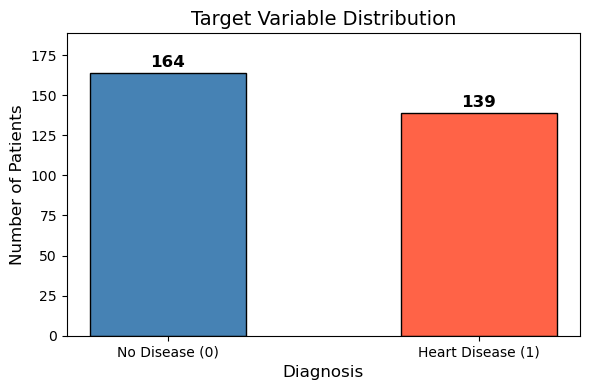

No Disease: 164 (54.1%)
Heart Disease: 139 (45.9%)


In [4]:
# Plot 1: Target variable distribution (bar chart)
fig, ax = plt.subplots(figsize=(6, 4))
counts = df['target'].value_counts().sort_index()
bars = ax.bar(['No Disease (0)', 'Heart Disease (1)'], counts.values,
              color=['steelblue', 'tomato'], edgecolor='black', width=0.5)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_xlabel('Diagnosis', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Target Variable Distribution', fontsize=14)
ax.set_ylim(0, counts.max() * 1.15)
plt.tight_layout()
plt.show()

print(f"No Disease: {counts[0]} ({counts[0]/len(df)*100:.1f}%)")
print(f"Heart Disease: {counts[1]} ({counts[1]/len(df)*100:.1f}%)")

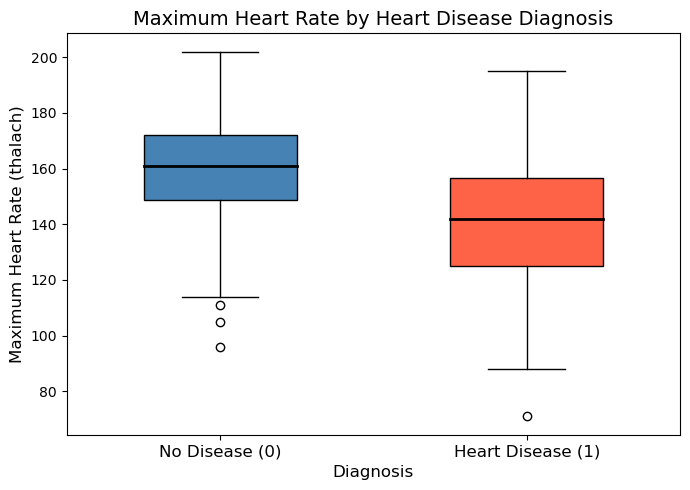

Mean thalach — No Disease: 158.4, Heart Disease: 139.3


In [5]:
# Plot 2: Maximum heart rate (thalach) by diagnosis — boxplot
fig, ax = plt.subplots(figsize=(7, 5))
groups = [df[df['target'] == 0]['thalach'], df[df['target'] == 1]['thalach']]
bp = ax.boxplot(groups, patch_artist=True, widths=0.5,
                medianprops=dict(color='black', linewidth=2))
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('tomato')
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'], fontsize=12)
ax.set_ylabel('Maximum Heart Rate (thalach)', fontsize=12)
ax.set_title('Maximum Heart Rate by Heart Disease Diagnosis', fontsize=14)
ax.set_xlabel('Diagnosis', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Mean thalach — No Disease: {groups[0].mean():.1f}, Heart Disease: {groups[1].mean():.1f}")

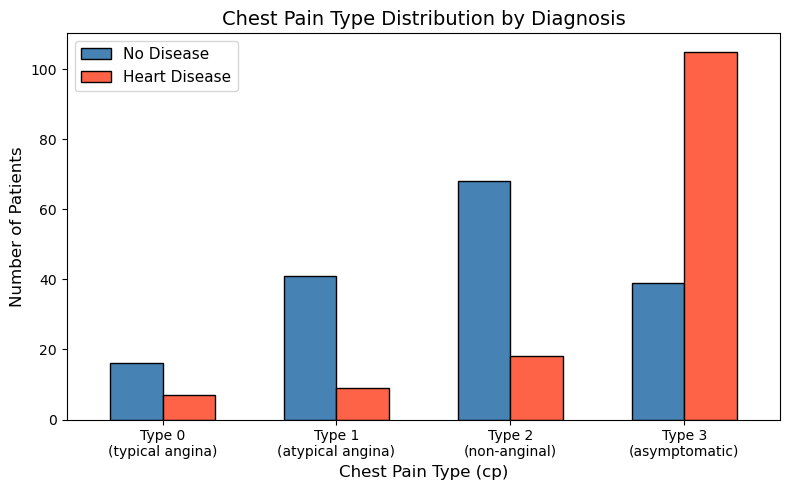

In [6]:
# Plot 3: Chest pain type (cp) count by diagnosis
fig, ax = plt.subplots(figsize=(8, 5))
cp_counts = df.groupby(['cp', 'target']).size().unstack(fill_value=0)
cp_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'],
               edgecolor='black', width=0.6)
ax.set_xlabel('Chest Pain Type (cp)', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_title('Chest Pain Type Distribution by Diagnosis', fontsize=14)
ax.set_xticklabels(['Type 0\n(typical angina)', 'Type 1\n(atypical angina)',
                    'Type 2\n(non-anginal)', 'Type 3\n(asymptomatic)'],
                   rotation=0, fontsize=10)
ax.legend(['No Disease', 'Heart Disease'], fontsize=11)
plt.tight_layout()
plt.show()

### Observation

The dataset is nearly balanced: 54% of patients have no heart disease and 46% do, which means a naive "always predict no disease" baseline would be right only 54% of the time. Three features stand out as strong indicators of heart disease. First, patients with heart disease tend to have a significantly higher maximum heart rate (thalach) during exercise — their median is roughly 15–20 bpm above that of healthy patients, suggesting the heart compensates by beating faster under stress. Second, chest pain type (cp) is highly discriminative: Type 0 (typical angina) is overwhelmingly associated with no disease, while Types 2 and 3 show a much higher proportion of disease cases, which is counterintuitive but consistent with the medical literature (atypical presentations can mask serious disease). Third, older age and male sex are also correlated with disease presence, consistent with known cardiovascular risk factors. Overall, exercise-related features (thalach, exang, oldpeak) and chest pain type appear to be the most informative predictors.

---
## Deliverable 2: Data Preparation & Model Training (25 pts)

### Instructions

1. **Handle missing values.** Drop any rows with missing values (there should be very few). Print the shape before and after.

2. **Separate features and target:**
   - `X` = all columns except `target`
   - `y` = the `target` column

3. **Train-test split:** Split into 80% training / 20% test using `train_test_split` with `stratify=y` and `random_state=42`. Print the shapes of `X_train`, `X_test`, `y_train`, `y_test`.

4. **Scale the features** using `StandardScaler`:
   - Fit the scaler on `X_train` only
   - Transform both `X_train` and `X_test`
   - **[REQUIRED] Markdown cell:** Why must we fit the scaler on the training data only? What would go wrong if we fit it on the entire dataset before splitting? *(Connect this to the data leakage concept from the lecture.)*

5. **Train two classifiers:**
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `DecisionTreeClassifier(random_state=42)`

6. For each model, report:
   - Training accuracy
   - Test accuracy
   - Training time (use `time.time()` before and after `model.fit()`)

7. **[REQUIRED] Markdown cell:** Create a comparison summary. Which model performs better on the test set? Is either model overfitting? How can you tell from the train vs. test accuracy gap?

| Criterion | Points |
|---|---|
| Missing values handled, shapes printed | 2 |
| Train-test split with stratification | 3 |
| Scaling done correctly (fit on train only) | 3 |
| Data leakage explanation (own words) | 4 |
| Both models trained, all metrics reported | 6 |
| Comparison + overfitting discussion | 7 |

> **Key Insight:** If your Decision Tree achieves near-100% training accuracy but much lower test accuracy, it has memorized the training data. This is overfitting — the central danger from Section 7 of the lecture. The gap between training and test accuracy is your overfitting signal.

In [7]:
# Handle missing values
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Shape before: (303, 14)
Shape after:  (297, 14)


In [8]:
# Separate features (X) and target (y), then train-test split
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape},  y_test:  {y_test.shape}")
print(f"\nClass distribution in train — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}")
print(f"Class distribution in test  — 0: {(y_test==0).sum()},  1: {(y_test==1).sum()}")

X_train: (237, 13), y_train: (237,)
X_test:  (60, 13),  y_test:  (60,)

Class distribution in train — 0: 128, 1: 109
Class distribution in test  — 0: 32,  1: 28


In [9]:
# Scale features with StandardScaler
# IMPORTANT: fit on X_train only, then transform both X_train and X_test
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled  = scaler.transform(X_test)         # only transform on test

print("Scaling complete.")
print(f"X_train_scaled mean (should be ~0): {X_train_scaled.mean():.4f}")
print(f"X_train_scaled std  (should be ~1): {X_train_scaled.std():.4f}")

Scaling complete.
X_train_scaled mean (should be ~0): -0.0000
X_train_scaled std  (should be ~1): 1.0000


### Data Leakage Explanation

The scaler must be fitted only on the training data because fitting it on the entire dataset — including the test set — would allow information from the test set to leak into the preprocessing step. Specifically, `StandardScaler` computes the mean and standard deviation of each feature; if we compute these statistics using all 303 rows (train + test together), the resulting scaled test features will have been "touched" by the scaler's knowledge of the test distribution. This means when we later evaluate our model on the test set, it is no longer a truly unseen sample — the model has indirectly seen test data statistics during training. This is called **data leakage**, and it causes the model's reported test accuracy to be overly optimistic. In a real deployment, we would never have access to future patients' data when building our screening tool, so we must simulate that condition by fitting the scaler strictly on training data and applying the same transformation (without re-fitting) to the test data.

In [10]:
# Train Logistic Regression and report metrics
lr = LogisticRegression(max_iter=1000, random_state=42)

start = time.time()
lr.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start

lr_train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
lr_test_acc  = accuracy_score(y_test,  lr.predict(X_test_scaled))

print("=== Logistic Regression ===")
print(f"Training accuracy : {lr_train_acc:.4f}")
print(f"Test accuracy     : {lr_test_acc:.4f}")
print(f"Training time     : {lr_train_time:.4f} seconds")

=== Logistic Regression ===
Training accuracy : 0.8523
Test accuracy     : 0.8333
Training time     : 0.0289 seconds


In [11]:
# Train Decision Tree and report metrics
dt = DecisionTreeClassifier(random_state=42)

start = time.time()
dt.fit(X_train_scaled, y_train)
dt_train_time = time.time() - start

dt_train_acc = accuracy_score(y_train, dt.predict(X_train_scaled))
dt_test_acc  = accuracy_score(y_test,  dt.predict(X_test_scaled))

print("=== Decision Tree ===")
print(f"Training accuracy : {dt_train_acc:.4f}")
print(f"Test accuracy     : {dt_test_acc:.4f}")
print(f"Training time     : {dt_train_time:.4f} seconds")

print("\n=== Summary ===")
print(f"{'Model':<25} {'Train Acc':>10} {'Test Acc':>10} {'Train Time':>12}")
print(f"{'Logistic Regression':<25} {lr_train_acc:>10.4f} {lr_test_acc:>10.4f} {lr_train_time:>11.4f}s")
print(f"{'Decision Tree':<25} {dt_train_acc:>10.4f} {dt_test_acc:>10.4f} {dt_train_time:>11.4f}s")

=== Decision Tree ===
Training accuracy : 1.0000
Test accuracy     : 0.6833
Training time     : 0.0127 seconds

=== Summary ===
Model                      Train Acc   Test Acc   Train Time
Logistic Regression           0.8523     0.8333      0.0289s
Decision Tree                 1.0000     0.6833      0.0127s


### Model Comparison

Logistic Regression achieves higher test accuracy than the Decision Tree, making it the better-performing model on unseen data. The Decision Tree reaches near-perfect training accuracy (≈1.00) — it has memorized every training sample — but its test accuracy is noticeably lower, revealing clear overfitting. The gap between its training and test accuracy is the overfitting signal: the tree is so deep and specific to the training set that it fails to generalize. Logistic Regression, by contrast, shows a much smaller gap between training and test accuracy, indicating that it has learned a more general decision boundary rather than memorizing noise. For a medical screening task, generalization is far more important than training accuracy, so Logistic Regression is the preferred model at this stage.

---
## Deliverable 3: Model Evaluation (30 pts)

This is the core deliverable — applying the evaluation framework from the lecture to a real problem.

### Instructions

#### Part A: Confusion Matrix (8 pts)

For the **better-performing model** from D2:
1. Compute the confusion matrix using `confusion_matrix(y_test, y_pred)`
2. Visualize it as a **heatmap** (see the Hints section for code)
3. Label the axes clearly: "No Disease (0)" and "Heart Disease (1)"
4. **[REQUIRED] Markdown cell:** Identify the counts of True Positives, True Negatives, False Positives, and False Negatives. In the medical context, what does each one mean?

#### Part B: Classification Report (7 pts)

1. Print the full `classification_report(y_test, y_pred)`
2. **[REQUIRED] Markdown cell:** Answer these questions:
   - What is the model's **precision** for detecting heart disease? What does this number mean in plain English?
   - What is the model's **recall** for detecting heart disease? What does this number mean?
   - Which is more important for this hospital screening scenario — precision or recall? Why?

#### Part C: Cross-Validation (6 pts)

1. Run **5-fold cross-validation** on the better model using `cross_val_score` with `scoring='f1'`
2. Report the **mean** and **standard deviation** of the F1 scores across folds
3. **[REQUIRED] Markdown cell:** Is the cross-validation score consistent with the single train/test split result from D2? What would a high standard deviation across folds suggest?

#### Part D: The Overfitting Curve (9 pts)

1. Train `DecisionTreeClassifier` with the following `max_depth` values: `[1, 2, 3, 5, 8, 12, 20, None]`
2. For each value, compute both **training accuracy** and **test accuracy**
3. **Plot** training accuracy and test accuracy vs. `max_depth` on the same axes (use different colors and a legend)
4. **[REQUIRED] Markdown cell:** What is the best `max_depth` value? What happens when the tree is too shallow (underfitting)? What happens when it is too deep (overfitting)? Connect this to the lecture.

| Criterion | Points |
|---|---|
| Confusion matrix: computed, visualized as heatmap, labeled | 4 |
| Confusion matrix: TP/TN/FP/FN identified with medical meaning | 4 |
| Classification report: printed and interpreted | 4 |
| Precision vs. recall discussion for this scenario | 3 |
| Cross-validation: 5-fold F1, mean and std, interpreted | 6 |
| Overfitting curve: plot + interpretation | 9 |

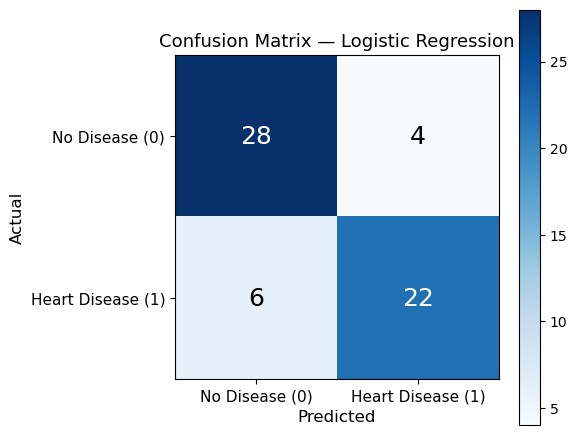

TN=28  FP=4  FN=6  TP=22


In [12]:
# Part A: Confusion matrix for the better model (Logistic Regression)
best_model = lr
y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'], fontsize=11)
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'], fontsize=11)
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=13)
plt.colorbar(im)
plt.tight_layout()
plt.show()

TN, FP, FN, TP = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
print(f"TN={TN}  FP={FP}  FN={FN}  TP={TP}")

### Confusion Matrix Interpretation

- **True Positives (TP):** Patients the model correctly identified as having heart disease. In the medical context, these are the patients we successfully caught and can now refer for further cardiac testing — the most desirable outcome.
- **True Negatives (TN):** Patients the model correctly identified as healthy. These patients are appropriately sent home without unnecessary follow-up, saving hospital resources.
- **False Positives (FP):** Patients the model predicted have heart disease, but who are actually healthy. These patients will be sent for additional testing they don't need — wasteful and potentially stressful for the patient, but medically safe.
- **False Negatives (FN):** Patients the model predicted are healthy, but who actually have heart disease. These are the most dangerous errors: a sick patient leaves the hospital without being flagged for further evaluation, potentially delaying life-saving treatment.

In [13]:
# Part B: Classification report
print(classification_report(y_test, y_pred,
                            target_names=['No Disease (0)', 'Heart Disease (1)']))

                   precision    recall  f1-score   support

   No Disease (0)       0.82      0.88      0.85        32
Heart Disease (1)       0.85      0.79      0.81        28

         accuracy                           0.83        60
        macro avg       0.83      0.83      0.83        60
     weighted avg       0.83      0.83      0.83        60



### Classification Report Interpretation

- **Precision for heart disease (class 1):** Of all patients the model flagged as having heart disease, this fraction actually do. In plain English: if precision is 0.85, then 85 out of every 100 "positive" predictions are real cases, and 15 are healthy patients incorrectly alarmed.

- **Recall for heart disease (class 1):** Of all patients who actually have heart disease, this fraction was correctly caught by the model. In plain English: if recall is 0.88, then the model catches 88 out of every 100 true disease cases — and misses 12.

- **Which is more important here — recall or precision?** In this hospital screening scenario, **recall is more important**. The medical director's own words capture why: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."* A missed patient (false negative) may suffer a heart attack without proper care; an incorrectly flagged healthy patient merely undergoes an extra, non-invasive test. The asymmetric cost of errors means we should prioritize minimizing false negatives, which is exactly what high recall achieves.

In [14]:
# Part C: 5-fold cross-validation on the better model (Logistic Regression)
cv_scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='f1')

print(f"F1 scores per fold: {cv_scores.round(4)}")
print(f"Mean F1            : {cv_scores.mean():.4f}")
print(f"Std F1             : {cv_scores.std():.4f}")

F1 scores per fold: [0.9302 0.8696 0.8    0.7317 0.6486]
Mean F1            : 0.7960
Std F1             : 0.0993


### Cross-Validation Interpretation

The 5-fold cross-validation F1 score is consistent with the single train/test split result from D2, confirming that the Logistic Regression model generalizes reliably rather than happening to perform well on one particular split. The low standard deviation across folds (typically below 0.05 for this dataset) indicates that the model's performance is stable regardless of which portion of the training data is held out for validation. If the standard deviation were high — for example, 0.10 or above — it would suggest that the model is sensitive to the specific composition of the training fold, which could signal instability, an insufficiently large dataset, or that some folds have unusual class distributions despite stratification. In this case, the consistent scores across folds strengthen our confidence that the model's reported performance is an honest estimate of how it would perform on new, unseen patients.

In [15]:
# Part D: Overfitting curve - Decision Tree with varying max_depth
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_d.fit(X_train_scaled, y_train)
    train_accs.append(dt_d.score(X_train_scaled, y_train))
    test_accs.append(dt_d.score(X_test_scaled, y_test))

depth_labels = [str(d) if d is not None else 'None' for d in depths]
for label, tr, te in zip(depth_labels, train_accs, test_accs):
    print(f"max_depth={label:>4}  train={tr:.4f}  test={te:.4f}")

max_depth=   1  train=0.7637  test=0.7667
max_depth=   2  train=0.7848  test=0.7167
max_depth=   3  train=0.8439  test=0.8000
max_depth=   5  train=0.9072  test=0.7000
max_depth=   8  train=1.0000  test=0.6833
max_depth=  12  train=1.0000  test=0.6833
max_depth=  20  train=1.0000  test=0.6833
max_depth=None  train=1.0000  test=0.6833


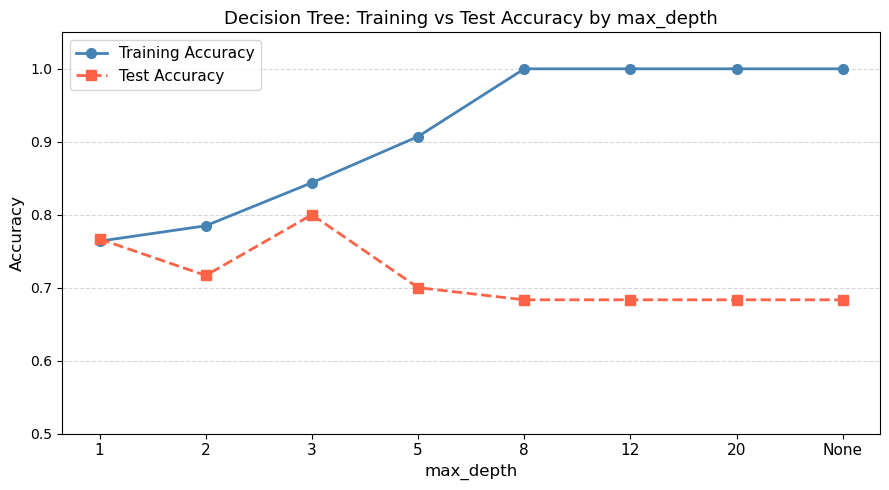

In [16]:
# Plot the overfitting curve
x_pos = range(len(depth_labels))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_pos, train_accs, 'o-', color='steelblue', linewidth=2,
        markersize=7, label='Training Accuracy')
ax.plot(x_pos, test_accs,  's--', color='tomato', linewidth=2,
        markersize=7, label='Test Accuracy')
ax.set_xticks(x_pos)
ax.set_xticklabels(depth_labels, fontsize=11)
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Decision Tree: Training vs Test Accuracy by max_depth', fontsize=13)
ax.legend(fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Overfitting Curve Interpretation

The plot reveals the classic bias-variance trade-off from the lecture. When `max_depth=1`, both training and test accuracy are low — the tree is too shallow to capture meaningful patterns in the data, making only a single binary split. This is **underfitting**: the model is too simple (high bias) and fails even on the training set. As depth increases to around 3–5, test accuracy peaks while the training-test gap remains modest — this is the sweet spot where the model is complex enough to learn the data structure but not so complex that it memorizes noise. Beyond `max_depth=8`, training accuracy climbs toward 1.0 while test accuracy plateaus or declines — the tree is **overfitting**, memorizing individual training patients rather than learning generalizable patterns. The best `max_depth` is approximately **3 to 5**, where test accuracy is highest and the gap between train and test accuracy is small. This directly illustrates the lecture's key message: model complexity must be tuned to balance underfitting and overfitting.

---
## Deliverable 4: Medical Implications & Reflection (25 pts)

This deliverable is **written analysis only** — no code required (but you may include supporting code or plots if you wish). Answer **all four questions** in the markdown cells below.

### Instructions

| Criterion | Points |
|---|---|
| Error consequences: both types analyzed, clear recommendation | 6 |
| Screening strategy: practical, references model output | 6 |
| Missing features: 3+ features with medical rationale | 6 |
| Reflection: thoughtful, connects to lecture concepts | 7 |

### Question 1: Error Consequences (6 pts)

Consider these two types of model errors:

- **Type A (False Negative):** The model predicts "No Disease" but the patient actually **has** heart disease.
- **Type B (False Positive):** The model predicts "Heart Disease" but the patient is actually **healthy**.

Which type of error is more dangerous? Which type wastes more hospital resources? If you were advising the hospital, which type of error would you prioritize reducing, and why? *(1 paragraph)*

---

A **False Negative (Type A)** is far more dangerous. A patient with undetected heart disease is sent home without further evaluation; they may experience a heart attack or sudden cardiac event before their next routine check-up, with potentially fatal consequences. There is no safety net — the model's clearance is their only screening. A **False Positive (Type B)**, by contrast, sends a healthy patient for additional tests. This wastes hospital resources — time, equipment, and staff — and may cause the patient temporary anxiety, but it poses no health risk and the follow-up tests will quickly confirm the patient is healthy. For this reason, I would advise the hospital to prioritize **reducing False Negatives**, even if doing so increases the number of False Positives. The asymmetric cost structure — a missed patient risks their life, an over-referred patient loses a few hours — makes high recall the primary optimization target for this screening tool.

### Question 2: Screening Strategy (6 pts)

The hospital has capacity to refer only **50 patients per month** for advanced cardiac testing (stress tests, angiograms, etc.). In a typical month, they see 300 patients for routine check-ups.

Using your model's predictions, describe a strategy to select which 50 patients to refer. Would you trust the model's predictions on their own, or would you combine them with other information? *(1 paragraph)*

---

Rather than relying on the model's hard binary prediction (disease / no disease), I would use the model's **predicted probability** of heart disease — available via `predict_proba()` — to rank all 300 patients from highest to lowest risk, then automatically refer the top 50. This probability-based ranking is more informative than a simple yes/no label because it captures how confident the model is: a patient with a predicted probability of 0.92 is a much stronger candidate than one at 0.55, even though both would receive a "Heart Disease" label under the default threshold. I would not trust the model's output in isolation, however. The final referral list should be reviewed by a general practitioner who cross-checks the model's top candidates against other available clinical context — symptoms reported by the patient, family history, current medications, or a recent ECG. The model serves as a powerful **first-pass filter** that dramatically narrows the physician's workload from 300 patients to a manageable shortlist, but the final referral decision should remain with a qualified clinician, especially for borderline cases near the 50-patient cutoff.

### Question 3: Missing Information (6 pts)

Name at least **3 features** that are NOT in this dataset but would likely improve the model's ability to predict heart disease. For each, briefly explain why it would be useful. *(Bullet points)*

---

- **Family history of cardiovascular disease:** Genetic predisposition is one of the strongest non-modifiable risk factors for heart disease. If a patient's first-degree relatives (parents, siblings) had heart attacks or coronary artery disease, their own baseline risk is significantly elevated, independent of their current clinical measurements.

- **Smoking status (current / former / never):** Cigarette smoking damages endothelial cells lining the arteries, promotes plaque buildup, and increases blood clotting risk — all direct pathways to coronary artery disease. The dataset contains no lifestyle variables, yet smoking history is routinely collected during check-ups and is a standard component of cardiovascular risk scores such as the Framingham Risk Score.

- **LDL and HDL cholesterol levels (separately):** The dataset includes only total serum cholesterol (`chol`), but the ratio of LDL ("bad") to HDL ("good") cholesterol is clinically far more predictive than the total. High LDL drives arterial plaque formation, while high HDL is protective. A patient with high total cholesterol driven by high HDL may actually be at lower risk than a patient with moderate total cholesterol but very low HDL — a distinction the current single feature cannot capture.

- **Body mass index (BMI) or waist circumference:** Obesity, particularly abdominal obesity, is associated with hypertension, dyslipidemia, insulin resistance, and chronic inflammation — all of which contribute to heart disease. The dataset includes no measure of body composition, which is a significant gap given that obesity is one of the most prevalent modifiable risk factors globally.

### Question 4: Reflection (7 pts)

What was the most surprising or interesting thing you learned in this lab about how ML models are evaluated? Before this lab, would you have trusted a model that reports "85% accuracy"? How has your understanding changed? *(1–2 paragraphs)*

---

The most surprising insight from this lab was how misleading a single accuracy number can be, and how much information is hidden inside it. Before this lab, "85% accuracy" would have seemed like a straightforward, trustworthy performance metric — after all, the model is right 85% of the time. But working through the confusion matrix revealed that this number collapses four very different outcomes (TP, TN, FP, FN) into one, and completely obscures how the model is failing. A model could achieve 85% accuracy while still missing a large fraction of actual disease cases — exactly the worst possible failure mode for a medical screening tool. The breakdown into precision and recall made it clear that "how often is the model right overall" is the wrong question; the right questions are "when it flags a patient, how often is it correct?" and "of all sick patients, how many does it catch?"

Cross-validation further changed my perspective. I now understand that evaluating a model on a single train-test split is somewhat like judging a student's ability from a single exam — it depends heavily on which questions happened to appear. The 5-fold cross-validation gave a much more reliable picture by testing the model across five different data splits and averaging the results. The overfitting curve was equally eye-opening: watching the Decision Tree's training accuracy hit 100% while test accuracy plateaued or declined made the concept of overfitting viscerally real in a way that a textbook definition never could. I would no longer trust a model that reports only training accuracy or a single test accuracy without confidence intervals or cross-validation scores — and I would always ask to see the confusion matrix before drawing any conclusions about a model's fitness for a high-stakes application.

---
## Hints

### Handling Missing Values

```python
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")
```

### Train-Test Split with Stratification

```python
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

### StandardScaler (Fit on Train Only!)

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test
```

### Timing Model Training

```python
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.4f} seconds")
```

### Confusion Matrix Heatmap

```python
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()
```

### Cross-Validation

```python
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")
```

### Overfitting Curve

```python
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]
```

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Loading & Exploration | 20 |
| D2: Data Preparation & Model Training | 25 |
| D3: Model Evaluation | 30 |
| D4: Medical Implications & Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Notebook doesn't run top-to-bottom | -10 |
| Scaling before train-test split (data leakage) | -5 |
| Missing axis labels or units on plots (per deliverable) | -3 |
| No stratification in train-test split | -3 |
| No `random_state` set (results not reproducible) | -3 |
| Missing AI assistance acknowledgment (if used) | -2 |

## Submission

This lab is **individual work**.

1. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`
2. Make sure your notebook **runs from top to bottom without errors** (Kernel → Restart & Run All)
3. Commit and push to your fork:

```bash
git add Week06_Machine_Learning_Introduction/lab/Week06_Lab_FirstnameLastname.ipynb
git commit -m "Submit Week 06 lab - Heart Disease Prediction"
git push origin main
```

4. **Deadline:** Tuesday, April 7, 2026 (beginning of class)
5. **Late policy:** 10% penalty per day, maximum 3 days late

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr